In [ ]:
import os
import time
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt

from pathlib import Path
from datetime import datetime
from PIL import Image

from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    matthews_corrcoef,
    ConfusionMatrixDisplay,
    classification_report,
    roc_curve,
    auc
)

from tensorflow.keras import layers, models, regularizers
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ModelCheckpoint, ReduceLROnPlateau, EarlyStopping
from tensorflow.keras.utils import Sequence

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("TensorFlow:", tf.__version__)
print("GPU:", tf.config.list_physical_devices("GPU"))

TensorFlow: 2.20.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [ ]:
import os
import random
import shutil
import numpy as np
import matplotlib.pyplot as plt

from PIL import Image
from collections import Counter

import tensorflow as tf
from tensorflow.keras import layers, models, regularizers
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ModelCheckpoint, ReduceLROnPlateau, EarlyStopping
from tensorflow.keras.utils import Sequence

from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    roc_auc_score,
    roc_curve,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.20.0


In [ ]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

In [ ]:
import zipfile
import os

zip_path = "/content/XRAYNEW.zip"   # change this
extract_path = "/content/dataset"       # output folder

os.makedirs(extract_path, exist_ok=True)

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Unzipped successfully!")
print("Extracted files are in:", extract_path)

Unzipped successfully!
Extracted files are in: /content/dataset


In [ ]:
DATA_DIR = "/content/dataset/XRAYNEW"   # change only if your path is different

print("DATA_DIR:", DATA_DIR)
print("Exists:", os.path.exists(DATA_DIR))

if os.path.exists(DATA_DIR):
    print("Folders:", os.listdir(DATA_DIR))
else:
    raise FileNotFoundError("DATA_DIR not found. Check your dataset path.")

DATA_DIR: /content/dataset/XRAYNEW
Exists: True
Folders: ['Benign', 'Malignant']


In [ ]:
import os

for root, dirs, files in os.walk("/content/dataset/XRAYNEW"):
    level = root.replace("/content/dataset", "").count(os.sep)
    indent = " " * 4 * level
    print(f"{indent}{os.path.basename(root)}/")
    subindent = " " * 4 * (level + 1)
    for d in dirs:
        print(f"{subindent}{d}/")

    XRAYNEW/
        Benign/
        Malignant/
        Benign/
        Malignant/


In [ ]:
DATA_DIR = "/content/dataset/XRAYNEW"

BENIGN_DIR = os.path.join(DATA_DIR, "benign")
MALIGNANT_DIR = os.path.join(DATA_DIR, "malignant")

print("Benign folder exists:", os.path.exists(BENIGN_DIR))
print("Malignant folder exists:", os.path.exists(MALIGNANT_DIR))

Benign folder exists: False
Malignant folder exists: False


In [ ]:
import os

base_path = "/content/dataset"

for root, dirs, files in os.walk(base_path):
    lower_dirs = [d.lower() for d in dirs]

    if "benign" in lower_dirs and "malignant" in lower_dirs:
        print("Found dataset folder:", root)
        print("Subfolders:", dirs)

Found dataset folder: /content/dataset/XRAYNEW
Subfolders: ['Benign', 'Malignant']


In [ ]:
import os

DATA_DIR = "/content/dataset/XRAYNEW"   # change after checking folder output

# Try different possible class folder names
possible_benign = ["benign", "Benign", "BENIGN"]
possible_malignant = ["malignant", "Malignant", "MALIGNANT"]

BENIGN_DIR = None
MALIGNANT_DIR = None

for name in possible_benign:
    path = os.path.join(DATA_DIR, name)
    if os.path.exists(path):
        BENIGN_DIR = path

for name in possible_malignant:
    path = os.path.join(DATA_DIR, name)
    if os.path.exists(path):
        MALIGNANT_DIR = path

print("DATA_DIR:", DATA_DIR)
print("BENIGN_DIR:", BENIGN_DIR)
print("MALIGNANT_DIR:", MALIGNANT_DIR)

if BENIGN_DIR is None or MALIGNANT_DIR is None:
    raise FileNotFoundError("Could not find benign/malignant folders. Please check DATA_DIR.")

DATA_DIR: /content/dataset/XRAYNEW
BENIGN_DIR: /content/dataset/XRAYNEW/Benign
MALIGNANT_DIR: /content/dataset/XRAYNEW/Malignant


In [ ]:
IMG_EXTENSIONS = (".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff")

image_paths = []
labels = []

for fname in os.listdir(BENIGN_DIR):
    if fname.lower().endswith(IMG_EXTENSIONS):
        image_paths.append(os.path.join(BENIGN_DIR, fname))
        labels.append(0)

for fname in os.listdir(MALIGNANT_DIR):
    if fname.lower().endswith(IMG_EXTENSIONS):
        image_paths.append(os.path.join(MALIGNANT_DIR, fname))
        labels.append(1)

import numpy as np
from collections import Counter

image_paths = np.array(image_paths)
labels = np.array(labels)

print("Total images:", len(image_paths))
print("Benign count:", np.sum(labels == 0))
print("Malignant count:", np.sum(labels == 1))
print("Label distribution:", Counter(labels))

Total images: 247
Benign count: 93
Malignant count: 154
Label distribution: Counter({np.int64(1): 154, np.int64(0): 93})


In [ ]:
def check_missing_files(paths, name):
    missing = []

    for p in paths:
        if not os.path.exists(str(p)):
            missing.append(str(p))

    print(f"{name}: total={len(paths)}, missing={len(missing)}")

    if len(missing) > 0:
        print("First missing files:")
        for m in missing[:10]:
            print(m)

    return missing


missing_all = check_missing_files(image_paths, "All images")

if len(missing_all) > 0:
    raise FileNotFoundError("Some image files are missing.")

All images: total=247, missing=0


In [ ]:
# 70% train, 30% temp
X_train, X_temp, y_train, y_temp = train_test_split(
    image_paths,
    labels,
    test_size=0.30,
    random_state=SEED,
    stratify=labels
)

# temp split into 15% val and 15% test
X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    random_state=SEED,
    stratify=y_temp
)

print("Train:", len(X_train), Counter(y_train))
print("Validation:", len(X_val), Counter(y_val))
print("Test:", len(X_test), Counter(y_test))

Train: 172 Counter({np.int64(1): 107, np.int64(0): 65})
Validation: 37 Counter({np.int64(1): 23, np.int64(0): 14})
Test: 38 Counter({np.int64(1): 24, np.int64(0): 14})


In [ ]:
classes = np.unique(y_train)

weights = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=y_train
)

class_weight_dict = dict(zip(classes, weights))

print("Class weights:", class_weight_dict)

Class weights: {np.int64(0): np.float64(1.323076923076923), np.int64(1): np.float64(0.8037383177570093)}


In [ ]:
IMG_SIZE = (300, 300)
BATCH_SIZE = 8


class XraySequence(Sequence):
    def __init__(self, image_paths, labels, batch_size=8, img_size=(300, 300), augment=False, shuffle=True):
        self.image_paths = np.array(image_paths)
        self.labels = np.array(labels)
        self.batch_size = batch_size
        self.img_size = img_size
        self.augment = augment
        self.shuffle = shuffle
        self.indices = np.arange(len(self.image_paths))

        self.augment_layer = tf.keras.Sequential([
            layers.RandomFlip("horizontal"),
            layers.RandomRotation(0.03),
            layers.RandomZoom(0.05),
        ])

        self.on_epoch_end()

    def __len__(self):
        return int(np.ceil(len(self.image_paths) / self.batch_size))

    def __getitem__(self, idx):
        batch_indices = self.indices[idx * self.batch_size:(idx + 1) * self.batch_size]

        batch_paths = self.image_paths[batch_indices]
        batch_labels = self.labels[batch_indices]

        images = []

        for path in batch_paths:
            img = Image.open(path).convert("RGB")
            img = img.resize(self.img_size)
            img = np.array(img).astype(np.float32)

            images.append(img)

        images = np.array(images, dtype=np.float32)
        batch_labels = np.array(batch_labels, dtype=np.float32)

        if self.augment:
            images = self.augment_layer(images, training=True)

        return images, batch_labels

    def on_epoch_end(self):
        if self.shuffle:
            np.random.shuffle(self.indices)

In [ ]:
train_ds = XraySequence(
    X_train,
    y_train,
    batch_size=BATCH_SIZE,
    img_size=IMG_SIZE,
    augment=True,
    shuffle=True
)

val_ds = XraySequence(
    X_val,
    y_val,
    batch_size=BATCH_SIZE,
    img_size=IMG_SIZE,
    augment=False,
    shuffle=False
)

test_ds = XraySequence(
    X_test,
    y_test,
    batch_size=BATCH_SIZE,
    img_size=IMG_SIZE,
    augment=False,
    shuffle=False
)

print("Train batches:", len(train_ds))
print("Val batches:", len(val_ds))
print("Test batches:", len(test_ds))

Train batches: 22
Val batches: 5
Test batches: 5


In [ ]:
def get_labels_from_sequence(seq):
    all_labels = []

    for i in range(len(seq)):
        _, y = seq[i]
        all_labels.extend(y)

    return np.array(all_labels).astype(int)


print("Train labels:", Counter(get_labels_from_sequence(train_ds)))
print("Val labels:", Counter(get_labels_from_sequence(val_ds)))
print("Test labels:", Counter(get_labels_from_sequence(test_ds)))

Train labels: Counter({np.int64(1): 107, np.int64(0): 65})
Val labels: Counter({np.int64(1): 23, np.int64(0): 14})
Test labels: Counter({np.int64(1): 24, np.int64(0): 14})


In [ ]:
def bilinear_first_order(b0_s, b1_s, a0_s, a1_s, K, Ts):
    c = 2.0 / Ts

    num0 = b0_s + b1_s * c
    num1 = b0_s - b1_s * c

    den0 = a0_s + a1_s * c
    den1 = a0_s - a1_s * c

    B0 = K * num0 / den0
    B1 = K * num1 / den0
    A1 = den1 / den0

    return B0, B1, A1


def get_lag_lead_coefficients(
    K=1.0,
    T1=0.2,
    beta=5.0,
    T2=0.1,
    alpha=0.2,
    Ts=1.0
):
    B0_lag, B1_lag, A1_lag = bilinear_first_order(
        b0_s=1.0,
        b1_s=T1,
        a0_s=1.0,
        a1_s=T1 * beta,
        K=K,
        Ts=Ts
    )

    B0_lead, B1_lead, A1_lead = bilinear_first_order(
        b0_s=1.0,
        b1_s=T2,
        a0_s=1.0,
        a1_s=alpha * T2,
        K=K,
        Ts=Ts
    )

    return {
        "B0_lag": B0_lag,
        "B1_lag": B1_lag,
        "A1_lag": A1_lag,
        "B0_lead": B0_lead,
        "B1_lead": B1_lead,
        "A1_lead": A1_lead
    }


coeffs_check = get_lag_lead_coefficients()
print(coeffs_check)

{'B0_lag': 0.4666666666666666, 'B1_lag': 0.19999999999999998, 'A1_lag': -0.3333333333333333, 'B0_lead': 1.1538461538461537, 'B1_lead': 0.7692307692307693, 'A1_lead': 0.923076923076923}


In [ ]:
class LagLead(layers.Layer):
    def __init__(self, alpha=0.15, beta=0.10, **kwargs):
        super(LagLeadPreprocessing, self).__init__(**kwargs)
        self.alpha = alpha
        self.beta = beta

    def call(self, inputs):
        # Low-pass / lag-like smoothing
        lag = tf.nn.avg_pool2d(
            inputs,
            ksize=3,
            strides=1,
            padding="SAME"
        )

        # High-frequency / lead-like residual
        lead = inputs - lag

        # Composite compensated image
        output = inputs + self.alpha * lag + self.beta * lead

        return output

In [ ]:
tf.keras.backend.clear_session()

base_model_lag = tf.keras.applications.EfficientNetB3(
    include_top=False,
    weights="imagenet",
    input_shape=(IMG_SIZE[0], IMG_SIZE[1], 3)
)

base_model_lag.trainable = False

inputs = layers.Input(shape=(IMG_SIZE[0], IMG_SIZE[1], 3))

x = LagLeadPreprocessing(alpha=0.15, beta=0.10, name="lag_lead_preprocessing")(inputs)

x = base_model_lag(x, training=False)
x = layers.GlobalAveragePooling2D()(x)

x = layers.BatchNormalization()(x)
x = layers.Dropout(0.4)(x)

x = layers.Dense(
    128,
    activation="relu",
    kernel_regularizer=regularizers.l2(1e-4)
)(x)

x = layers.BatchNormalization()(x)
x = layers.Dropout(0.3)(x)

outputs = layers.Dense(1, activation="sigmoid")(x)

laglead_model = models.Model(inputs, outputs)

laglead_model.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss="binary_crossentropy",
    metrics=[
        "accuracy",
        tf.keras.metrics.Precision(name="precision"),
        tf.keras.metrics.Recall(name="recall"),
        tf.keras.metrics.AUC(name="auc")
    ]
)

laglead_model.summary()

43941136/43941136 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 300, 300, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lag_lead_preprocessing          │ (None, 300, 300, 3)    │             0 │
│ (LagLeadPreprocessing)          │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb3 (Functional)     │ (None, 10, 10, 1536)   │    10,783,535 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1536)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 1536)           │         6,144 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1536)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       196,736 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10,987,056 (41.91 MB)

 Trainable params: 200,193 (782.00 KB)

 Non-trainable params: 10,786,863 (41.15 MB)

In [ ]:
checkpoint_lag = ModelCheckpoint(
    "best_xray_laglead_efficientnetb3.keras",
    monitor="val_auc",
    mode="max",
    save_best_only=True,
    verbose=1
)

reduce_lr_lag = ReduceLROnPlateau(
    monitor="val_auc",
    mode="max",
    factor=0.5,
    patience=5,
    min_lr=1e-7,
    verbose=1
)

early_stop_lag = EarlyStopping(
    monitor="val_auc",
    mode="max",
    patience=15,
    restore_best_weights=True,
    verbose=1
)

history_lag1 = laglead_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=40,
    callbacks=[checkpoint_lag, reduce_lr_lag, early_stop_lag],
    class_weight=class_weight_dict,
    verbose=1
)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/40
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.4921 - auc: 0.5010 - loss: 0.9513 - precision: 0.6249 - recall: 0.4936
Epoch 1: val_auc improved from None to 0.48758, saving model to best_xray_laglead_efficientnetb3.keras

Epoch 1: finished saving model to best_xray_laglead_efficientnetb3.keras
22/22 ━━━━━━━━━━━━━━━━━━━━ 123s 3s/step - accuracy: 0.4826 - auc: 0.5002 - loss: 0.9664 - precision: 0.6047 - recall: 0.4860 - val_accuracy: 0.4865 - val_auc: 0.4876 - val_loss: 0.7584 - val_precision: 0.7500 - val_recall: 0.2609 - learning_rate: 1.0000e-04
Epoch 2/40
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 421ms/step - accuracy: 0.5036 - auc: 0.4808 - loss: 1.1181 - precision: 0.5742 - recall: 0.5733
Epoch 2: val_auc did not improve from 0.48758
22/22 ━━━━━━━━━━━━━━━━━━━━ 11s 514ms/step - accuracy: 0.5233 - auc: 0.5151 - loss: 0.9806 - precision: 0.6404 - recall: 0.5327 - val_accuracy: 0.4865 - val_auc: 0.4689 - val_loss: 0.7850 - val_precision: 0.8333 - val_recall: 0.2174 - learning_rate:

In [ ]:
base_model_lag.trainable = True

for layer in base_model_lag.layers[:-40]:
    layer.trainable = False

laglead_model.compile(
    optimizer=Adam(learning_rate=1e-5),
    loss="binary_crossentropy",
    metrics=[
        "accuracy",
        tf.keras.metrics.Precision(name="precision"),
        tf.keras.metrics.Recall(name="recall"),
        tf.keras.metrics.AUC(name="auc")
    ]
)

history_lag2 = laglead_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=40,
    callbacks=[checkpoint_lag, reduce_lr_lag, early_stop_lag],
    class_weight=class_weight_dict,
    verbose=1
)

Epoch 1/40
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.6616 - auc: 0.7252 - loss: 0.6776 - precision: 0.7875 - recall: 0.6329
Epoch 1: val_auc improved from 0.64286 to 0.64596, saving model to best_xray_laglead_efficientnetb3.keras

Epoch 1: finished saving model to best_xray_laglead_efficientnetb3.keras
22/22 ━━━━━━━━━━━━━━━━━━━━ 108s 3s/step - accuracy: 0.5930 - auc: 0.6625 - loss: 0.7660 - precision: 0.7126 - recall: 0.5794 - val_accuracy: 0.5405 - val_auc: 0.6460 - val_loss: 0.8393 - val_precision: 0.7500 - val_recall: 0.3913 - learning_rate: 1.0000e-05
Epoch 2/40
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 419ms/step - accuracy: 0.6416 - auc: 0.6876 - loss: 0.6794 - precision: 0.7517 - recall: 0.6747
Epoch 2: val_auc improved from 0.64596 to 0.65839, saving model to best_xray_laglead_efficientnetb3.keras

Epoch 2: finished saving model to best_xray_laglead_efficientnetb3.keras
22/22 ━━━━━━━━━━━━━━━━━━━━ 14s 620ms/step - accuracy: 0.6628 - auc: 0.7132 - loss: 0.6632 - precision: 0.7475 -

In [ ]:
best_laglead_model = tf.keras.models.load_model(
    "best_xray_laglead_efficientnetb3.keras",
    custom_objects={"LagLeadPreprocessing": LagLeadPreprocessing}
)

test_loss, test_acc, test_precision, test_recall, test_auc = best_laglead_model.evaluate(test_ds, verbose=1)

print("Lag-Lead Test Loss:", test_loss)
print("Lag-Lead Test Accuracy:", test_acc)
print("Lag-Lead Test Precision:", test_precision)
print("Lag-Lead Test Recall:", test_recall)
print("Lag-Lead Test AUC:", test_auc)

5/5 ━━━━━━━━━━━━━━━━━━━━ 40s 7s/step - accuracy: 0.4211 - auc: 0.5119 - loss: 1.0976 - precision: 0.5833 - recall: 0.2917
Lag-Lead Test Loss: 1.0975905656814575
Lag-Lead Test Accuracy: 0.42105263471603394
Lag-Lead Test Precision: 0.5833333134651184
Lag-Lead Test Recall: 0.2916666567325592
Lag-Lead Test AUC: 0.5119047164916992


In [ ]:
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score, accuracy_score, precision_score, recall_score, f1_score

# Get true labels from generator
y_test_true = []
for i in range(len(test_ds)):
    _, y_batch = test_ds[i]
    y_test_true.extend(y_batch)

y_test_true = np.array(y_test_true).astype(int)  # convert to int
print("True labels shape:", y_test_true.shape)

# Get predicted probabilities
test_pred_prob = best_laglead_model.predict(test_ds)
# Flatten if needed
if test_pred_prob.ndim > 1:
    test_pred_prob = test_pred_prob.ravel()

# Convert probabilities to binary class
test_pred_class = (test_pred_prob >= 0.5).astype(int)

print("Predicted labels shape:", test_pred_class.shape)

# Confusion matrix
cm = confusion_matrix(y_test_true, test_pred_class)
print("Confusion Matrix:")
print(cm)

# Classification report
print("\nClassification Report:")
print(classification_report(
    y_test_true,
    test_pred_class,
    target_names=["Benign", "Malignant"]
))

# Compute metrics
test_auc_score = roc_auc_score(y_test_true, test_pred_prob)
test_accuracy = accuracy_score(y_test_true, test_pred_class)
test_precision = precision_score(y_test_true, test_pred_class)
test_recall = recall_score(y_test_true, test_pred_class)
test_f1 = f1_score(y_test_true, test_pred_class)

tn, fp, fn, tp = cm.ravel()
specificity = tn / (tn + fp)

print("Final Lag-Lead Test Metrics")
print("Accuracy:", test_accuracy)
print("Precision:", test_precision)
print("Recall / Sensitivity:", test_recall)
print("Specificity:", specificity)
print("F1-score:", test_f1)
print("AUC:", test_auc_score)

True labels shape: (38,)
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 378ms/step
Predicted labels shape: (38,)
Confusion Matrix:
[[ 9  5]
 [17  7]]

Classification Report:
              precision    recall  f1-score   support

      Benign       0.35      0.64      0.45        14
   Malignant       0.58      0.29      0.39        24

    accuracy                           0.42        38
   macro avg       0.46      0.47      0.42        38
weighted avg       0.50      0.42      0.41        38

Final Lag-Lead Test Metrics
Accuracy: 0.42105263157894735
Precision: 0.5833333333333334
Recall / Sensitivity: 0.2916666666666667
Specificity: 0.6428571428571429
F1-score: 0.3888888888888889
AUC: 0.5119047619047619


5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 393ms/step
True label count: Counter({np.int64(1): 24, np.int64(0): 14})
Predicted label count: Counter({np.int64(0): 26, np.int64(1): 12})
Confusion Matrix:
[[ 9  5]
 [17  7]]

Classification Report:
              precision    recall  f1-score   support

      Benign       0.35      0.64      0.45        14
   Malignant       0.58      0.29      0.39        24

    accuracy                           0.42        38
   macro avg       0.46      0.47      0.42        38
weighted avg       0.50      0.42      0.41        38



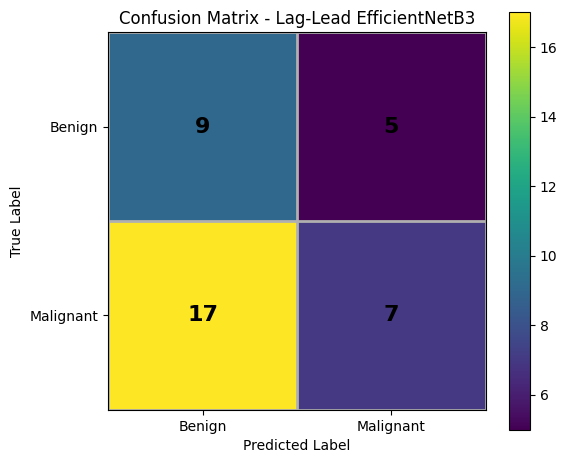

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report
from collections import Counter

# -------------------------------
# 1. Get true labels correctly
# -------------------------------
def get_labels_from_sequence(seq):
    labels = []
    for i in range(len(seq)):
        _, y_batch = seq[i]
        y_batch = np.array(y_batch).ravel()
        labels.extend(y_batch)
    return np.array(labels).astype(int)

y_test_true = get_labels_from_sequence(test_ds)

# -------------------------------
# 2. Get predicted labels correctly
# -------------------------------
test_pred_prob = best_laglead_model.predict(test_ds).ravel()
test_pred_class = (test_pred_prob >= 0.5).astype(int)

print("True label count:", Counter(y_test_true))
print("Predicted label count:", Counter(test_pred_class))

# -------------------------------
# 3. Confusion matrix
# -------------------------------
cm = confusion_matrix(
    y_test_true,
    test_pred_class,
    labels=[0, 1]
)

print("Confusion Matrix:")
print(cm)

print("\nClassification Report:")
print(classification_report(
    y_test_true,
    test_pred_class,
    labels=[0, 1],
    target_names=["Benign", "Malignant"],
    zero_division=0
))

# -------------------------------
# 4. Plot proper confusion matrix box
# -------------------------------
class_names = ["Benign", "Malignant"]

fig, ax = plt.subplots(figsize=(6, 5))

im = ax.imshow(cm)

ax.set_title("Confusion Matrix - Lag-Lead EfficientNetB3")
ax.set_xlabel("Predicted Label")
ax.set_ylabel("True Label")

ax.set_xticks(np.arange(len(class_names)))
ax.set_yticks(np.arange(len(class_names)))

ax.set_xticklabels(class_names)
ax.set_yticklabels(class_names)

# Write numbers inside boxes
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(
            j,
            i,
            cm[i, j],
            ha="center",
            va="center",
            fontsize=16,
            fontweight="bold"
        )

# Add grid-like box borders
ax.set_xticks(np.arange(-0.5, len(class_names), 1), minor=True)
ax.set_yticks(np.arange(-0.5, len(class_names), 1), minor=True)
ax.grid(which="minor", linestyle="-", linewidth=2)
ax.tick_params(which="minor", bottom=False, left=False)

plt.colorbar(im, ax=ax)
plt.tight_layout()
plt.show()

In [ ]:
import numpy as np
import pandas as pd
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    matthews_corrcoef,
    classification_report
)

# -------------------------------
# 1. Get true labels
# -------------------------------
def get_labels_from_sequence(seq):
    labels = []
    for i in range(len(seq)):
        _, y_batch = seq[i]
        y_batch = np.array(y_batch).ravel()
        labels.extend(y_batch)
    return np.array(labels).astype(int)

y_true = get_labels_from_sequence(test_ds)

# -------------------------------
# 2. Get predicted probabilities
# -------------------------------
y_prob = best_laglead_model.predict(test_ds).ravel()

# -------------------------------
# 3. Convert probability to class
# -------------------------------
threshold = 0.5
y_pred = (y_prob >= threshold).astype(int)

# -------------------------------
# 4. Confusion matrix
# -------------------------------
cm = confusion_matrix(y_true, y_pred, labels=[0, 1])

tn, fp, fn, tp = cm.ravel()

print("Confusion Matrix:")
print(cm)

print("\nClassification Report:")
print(classification_report(
    y_true,
    y_pred,
    labels=[0, 1],
    target_names=["Benign", "Malignant"],
    zero_division=0
))

# -------------------------------
# 5. Calculate metrics
# -------------------------------
accuracy = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred, zero_division=0)
sensitivity = recall_score(y_true, y_pred, zero_division=0)   # malignant recall
f1 = f1_score(y_true, y_pred, zero_division=0)
auc_score = roc_auc_score(y_true, y_prob)
mcc = matthews_corrcoef(y_true, y_pred)

specificity = tn / (tn + fp) if (tn + fp) > 0 else 0

# -------------------------------
# 6. Save results to Excel
# -------------------------------
results_dict = {
    "accuracy": accuracy,
    "precision": precision,
    "sensitivity_recall": sensitivity,
    "specificity": specificity,
    "f1_score": f1,
    "auc": auc_score,
    "mcc": mcc,
    "tn": tn,
    "fp": fp,
    "fn": fn,
    "tp": tp,
    "probability_min": np.min(y_prob),
    "probability_max": np.max(y_prob),
    "probability_mean": np.mean(y_prob),
    "probability_std": np.std(y_prob)
}

results_df = pd.DataFrame([results_dict])

results_file = "test_results_laglead_model.xlsx"
results_df.to_excel(results_file, index=False)

cm_df = pd.DataFrame(
    cm,
    index=["Actual Benign", "Actual Malignant"],
    columns=["Predicted Benign", "Predicted Malignant"]
)

cm_file = "confusion_matrix_laglead_model.xlsx"
cm_df.to_excel(cm_file)

print("\nSaved files:")
print(results_file)
print(cm_file)

print("\nFinal Lag-Lead Test Metrics:")
print("Accuracy:", accuracy)
print("Precision:", precision)
print("Sensitivity / Recall:", sensitivity)
print("Specificity:", specificity)
print("F1-score:", f1)
print("AUC:", auc_score)
print("MCC:", mcc)
print("TN:", tn)
print("FP:", fp)
print("FN:", fn)
print("TP:", tp)

5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 378ms/step
Confusion Matrix:
[[ 9  5]
 [17  7]]

Classification Report:
              precision    recall  f1-score   support

      Benign       0.35      0.64      0.45        14
   Malignant       0.58      0.29      0.39        24

    accuracy                           0.42        38
   macro avg       0.46      0.47      0.42        38
weighted avg       0.50      0.42      0.41        38


Saved files:
test_results_laglead_model.xlsx
confusion_matrix_laglead_model.xlsx

Final Lag-Lead Test Metrics:
Accuracy: 0.42105263157894735
Precision: 0.5833333333333334
Sensitivity / Recall: 0.2916666666666667
Specificity: 0.6428571428571429
F1-score: 0.3888888888888889
AUC: 0.5119047619047619
MCC: -0.0679478540272676
TN: 9
FP: 5
FN: 17
TP: 7


In [ ]:
# =========================================================
# BOOTSTRAP 95% CONFIDENCE INTERVALS FOR TEST METRICS
# =========================================================

import numpy as np
import pandas as pd
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, matthews_corrcoef
)

def compute_all_metrics(y_true, y_prob, threshold=0.5):
    y_pred = (y_prob >= threshold).astype(int)

    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, zero_division=0)
    sens = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)
    mcc = matthews_corrcoef(y_true, y_pred)

    try:
        auc_val = roc_auc_score(y_true, y_prob)
    except ValueError:
        auc_val = np.nan

    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    spec = tn / (tn + fp + 1e-8)

    return {
        "accuracy": acc,
        "precision": prec,
        "sensitivity": sens,
        "specificity": spec,
        "f1_score": f1,
        "auc": auc_val,
        "mcc": mcc,
        "tn": tn,
        "fp": fp,
        "fn": fn,
        "tp": tp
    }


def bootstrap_95ci(y_true, y_prob, n_bootstrap=2000, seed=42):
    rng = np.random.default_rng(seed)

    y_true = np.array(y_true)
    y_prob = np.array(y_prob)

    metric_names = [
        "accuracy",
        "precision",
        "sensitivity",
        "specificity",
        "f1_score",
        "auc",
        "mcc"
    ]

    original = compute_all_metrics(y_true, y_prob)

    boot_values = {m: [] for m in metric_names}
    n = len(y_true)

    for _ in range(n_bootstrap):
        idx = rng.choice(np.arange(n), size=n, replace=True)

        y_true_b = y_true[idx]
        y_prob_b = y_prob[idx]

        # AUC requires both classes
        if len(np.unique(y_true_b)) < 2:
            continue

        metrics_b = compute_all_metrics(y_true_b, y_prob_b)

        for m in metric_names:
            boot_values[m].append(metrics_b[m])

    rows = []

    for m in metric_names:
        values = np.array(boot_values[m])

        ci_low = np.percentile(values, 2.5)
        ci_high = np.percentile(values, 97.5)

        rows.append({
            "Metric": m,
            "Value": original[m],
            "95% CI Lower": ci_low,
            "95% CI Upper": ci_high,
            "Report format": f"{original[m]:.4f} [{ci_low:.4f}, {ci_high:.4f}]"
        })

    ci_df = pd.DataFrame(rows)

    return original, ci_df


test_metrics, test_ci_df = bootstrap_95ci(
    y_true=y_test,
    y_prob=y_prob,
    n_bootstrap=2000,
    seed=42
)

display(test_ci_df)

test_ci_df.to_excel("heldout_test_metrics_with_95CI.xlsx", index=False)

print("Saved: heldout_test_metrics_with_95CI.xlsx")

,Metric,Value,95% CI Lower,95% CI Upper,Report format
0,accuracy,0.421053,0.263158,0.578947,"0.4211 [0.2632, 0.5789]"
1,precision,0.583333,0.285714,0.866667,"0.5833 [0.2857, 0.8667]"
2,sensitivity,0.291667,0.125000,0.481513,"0.2917 [0.1250, 0.4815]"
3,specificity,0.642857,0.384615,0.888889,"0.6429 [0.3846, 0.8889]"
4,f1_score,0.388889,0.181818,0.571617,"0.3889 [0.1818, 0.5716]"
5,auc,0.511905,0.312446,0.720546,"0.5119 [0.3124, 0.7205]"
6,mcc,-0.067948,-0.395907,0.251230,"-0.0679 [-0.3959, 0.2512]"


Saved: heldout_test_metrics_with_95CI.xlsx


In [ ]:
# =========================================================
# SAVE CONFUSION MATRIX TABLE
# =========================================================

cm = confusion_matrix(y_test, y_pred)

cm_df = pd.DataFrame(
    cm,
    index=["Actual Benign", "Actual Malignant"],
    columns=["Predicted Benign", "Predicted Malignant"]
)

display(cm_df)

cm_df.to_excel("confusion_matrix_test_set.xlsx")

print("Saved: confusion_matrix_test_set.xlsx")

,Predicted Benign,Predicted Malignant
Actual Benign,9,5
Actual Malignant,17,7


Saved: confusion_matrix_test_set.xlsx


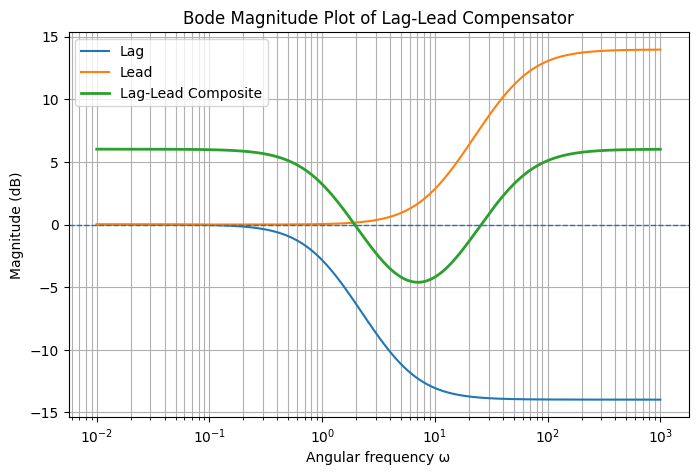

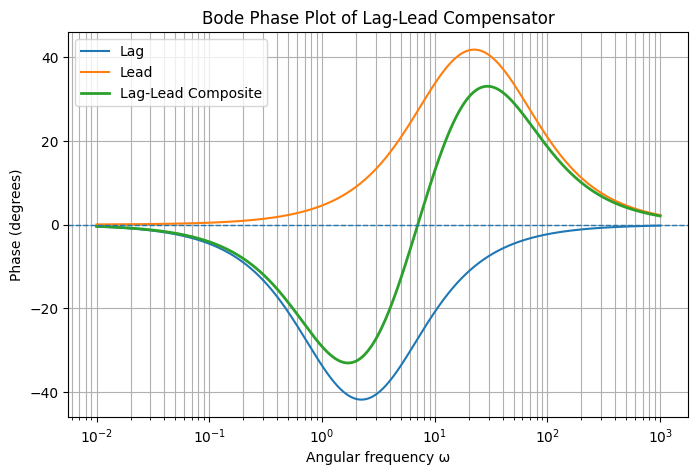

Low-frequency composite gain:
Magnitude: 1.9999049672490443
dB: 6.020187181480385

High-frequency composite gain:
Magnitude: 1.9976285215796297
dB: 6.01029460244673

Peak composite gain:
Peak dB: 6.020187181480385
Peak frequency: 0.01


In [ ]:
# =========================================================
# LAG-LEAD BODE PLOT
# =========================================================

import numpy as np
import matplotlib.pyplot as plt

# =========================================================
# Parameters used in your model
# =========================================================
K = 2.0       # use K=2.0 if you want approximately +6 dB gain shift
T1 = 0.2
T2 = 0.1
beta = 5.0
alpha = 0.2

# =========================================================
# Analog transfer functions:
# Lag  = (1 + T1*s) / (1 + beta*T1*s)
# Lead = (1 + T2*s) / (1 + alpha*T2*s)
# Composite = K * Lag * Lead
# =========================================================

w = np.logspace(-2, 3, 2000)   # rad/sample or normalized radian frequency
s = 1j * w

H_lag = (1 + T1 * s) / (1 + beta * T1 * s)
H_lead = (1 + T2 * s) / (1 + alpha * T2 * s)
H_composite = K * H_lag * H_lead

mag_lag_db = 20 * np.log10(np.abs(H_lag))
mag_lead_db = 20 * np.log10(np.abs(H_lead))
mag_composite_db = 20 * np.log10(np.abs(H_composite))

phase_lag = np.angle(H_lag, deg=True)
phase_lead = np.angle(H_lead, deg=True)
phase_composite = np.angle(H_composite, deg=True)

# =========================================================
# Magnitude plot
# =========================================================

plt.figure(figsize=(8, 5))
plt.semilogx(w, mag_lag_db, label="Lag")
plt.semilogx(w, mag_lead_db, label="Lead")
plt.semilogx(w, mag_composite_db, label="Lag-Lead Composite", linewidth=2)

plt.axhline(0, linestyle="--", linewidth=1)
plt.xlabel("Angular frequency ω")
plt.ylabel("Magnitude (dB)")
plt.title("Bode Magnitude Plot of Lag-Lead Compensator")
plt.grid(True, which="both")
plt.legend()
plt.show()

# =========================================================
# Phase plot
# =========================================================

plt.figure(figsize=(8, 5))
plt.semilogx(w, phase_lag, label="Lag")
plt.semilogx(w, phase_lead, label="Lead")
plt.semilogx(w, phase_composite, label="Lag-Lead Composite", linewidth=2)

plt.axhline(0, linestyle="--", linewidth=1)
plt.xlabel("Angular frequency ω")
plt.ylabel("Phase (degrees)")
plt.title("Bode Phase Plot of Lag-Lead Compensator")
plt.grid(True, which="both")
plt.legend()
plt.show()

# =========================================================
# Print gain values
# =========================================================

print("Low-frequency composite gain:")
print("Magnitude:", np.abs(H_composite[0]))
print("dB:", mag_composite_db[0])

print("\nHigh-frequency composite gain:")
print("Magnitude:", np.abs(H_composite[-1]))
print("dB:", mag_composite_db[-1])

print("\nPeak composite gain:")
print("Peak dB:", np.max(mag_composite_db))
print("Peak frequency:", w[np.argmax(mag_composite_db)])

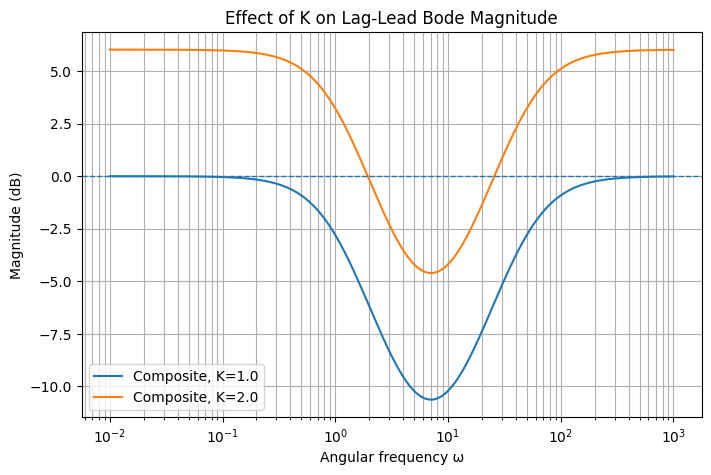

High-frequency gain K=1: -0.010305310832894564 dB
High-frequency gain K=2: 6.01029460244673 dB


In [ ]:
# =========================================================
# COMPARE K = 1 AND K = 2
# =========================================================

def composite_response(w, K, T1, T2, beta, alpha):
    s = 1j * w
    H_lag = (1 + T1 * s) / (1 + beta * T1 * s)
    H_lead = (1 + T2 * s) / (1 + alpha * T2 * s)
    H = K * H_lag * H_lead
    return H

w = np.logspace(-2, 3, 2000)

H_K1 = composite_response(w, 1.0, T1, T2, beta, alpha)
H_K2 = composite_response(w, 2.0, T1, T2, beta, alpha)

plt.figure(figsize=(8, 5))
plt.semilogx(w, 20 * np.log10(np.abs(H_K1)), label="Composite, K=1.0")
plt.semilogx(w, 20 * np.log10(np.abs(H_K2)), label="Composite, K=2.0")
plt.axhline(0, linestyle="--", linewidth=1)

plt.xlabel("Angular frequency ω")
plt.ylabel("Magnitude (dB)")
plt.title("Effect of K on Lag-Lead Bode Magnitude")
plt.grid(True, which="both")
plt.legend()
plt.show()

print("High-frequency gain K=1:", 20 * np.log10(np.abs(H_K1[-1])), "dB")
print("High-frequency gain K=2:", 20 * np.log10(np.abs(H_K2[-1])), "dB")

Digital coefficients:
B0_lag = 0.4666666666666666
B1_lag = 0.19999999999999998
A1_lag = -0.3333333333333333
B0_lead = 1.1538461538461537
B1_lead = 0.7692307692307693
A1_lead = 0.923076923076923


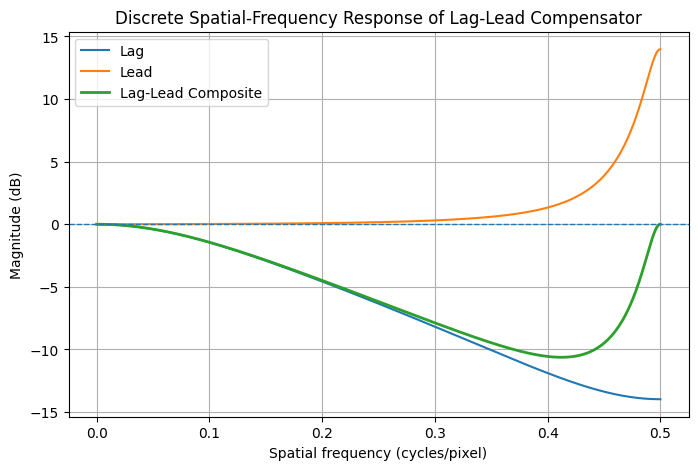

Composite magnitude at 0 cycles/pixel: 8.684733163774562e-12 dB
Composite magnitude at Nyquist 0.5 cycles/pixel: 8.673161234175933e-12 dB
Peak composite magnitude: 8.684733163774562e-12 dB


In [ ]:
# =========================================================
# DISCRETE SPATIAL-FREQUENCY RESPONSE
# Axis: cycles/pixel
# =========================================================

import numpy as np
import matplotlib.pyplot as plt

K = 1.0
T1 = 0.2
T2 = 0.1
beta = 5.0
alpha = 0.2
Ts = 1.0

# =========================================================
# Bilinear transform coefficient function
# Same structure as your model code
# =========================================================

def bilinear_first_order(b0_s, b1_s, a0_s, a1_s, K, Ts):
    c = 2.0 / Ts

    num0 = b0_s + b1_s * c
    num1 = b0_s - b1_s * c

    den0 = a0_s + a1_s * c
    den1 = a0_s - a1_s * c

    B0 = K * num0 / den0
    B1 = K * num1 / den0
    A1 = den1 / den0

    return B0, B1, A1


def get_lag_lead_coefficients(K=1.0, T1=0.2, beta=5.0, T2=0.1, alpha=0.2, Ts=1.0):
    B0_lag, B1_lag, A1_lag = bilinear_first_order(
        b0_s=1.0,
        b1_s=T1,
        a0_s=1.0,
        a1_s=T1 * beta,
        K=K,
        Ts=Ts
    )

    B0_lead, B1_lead, A1_lead = bilinear_first_order(
        b0_s=1.0,
        b1_s=T2,
        a0_s=1.0,
        a1_s=alpha * T2,
        K=K,
        Ts=Ts
    )

    return {
        "B0_lag": B0_lag,
        "B1_lag": B1_lag,
        "A1_lag": A1_lag,
        "B0_lead": B0_lead,
        "B1_lead": B1_lead,
        "A1_lead": A1_lead
    }


coeffs = get_lag_lead_coefficients(
    K=K,
    T1=T1,
    beta=beta,
    T2=T2,
    alpha=alpha,
    Ts=Ts
)

print("Digital coefficients:")
for k, v in coeffs.items():
    print(k, "=", v)

# =========================================================
# Digital frequency response:
# H(z) = (B0 + B1 z^-1) / (1 + A1 z^-1)
# =========================================================

freq_cyc_per_pixel = np.linspace(0, 0.5, 1000)
omega = 2 * np.pi * freq_cyc_per_pixel

z_inv = np.exp(-1j * omega)

H_lag_z = (
    coeffs["B0_lag"] + coeffs["B1_lag"] * z_inv
) / (
    1 + coeffs["A1_lag"] * z_inv
)

H_lead_z = (
    coeffs["B0_lead"] + coeffs["B1_lead"] * z_inv
) / (
    1 + coeffs["A1_lead"] * z_inv
)

H_composite_z = H_lag_z * H_lead_z

mag_lag_db = 20 * np.log10(np.abs(H_lag_z) + 1e-12)
mag_lead_db = 20 * np.log10(np.abs(H_lead_z) + 1e-12)
mag_composite_db = 20 * np.log10(np.abs(H_composite_z) + 1e-12)

plt.figure(figsize=(8, 5))
plt.plot(freq_cyc_per_pixel, mag_lag_db, label="Lag")
plt.plot(freq_cyc_per_pixel, mag_lead_db, label="Lead")
plt.plot(freq_cyc_per_pixel, mag_composite_db, label="Lag-Lead Composite", linewidth=2)
plt.axhline(0, linestyle="--", linewidth=1)

plt.xlabel("Spatial frequency (cycles/pixel)")
plt.ylabel("Magnitude (dB)")
plt.title("Discrete Spatial-Frequency Response of Lag-Lead Compensator")
plt.grid(True)
plt.legend()
plt.show()

print("Composite magnitude at 0 cycles/pixel:", mag_composite_db[0], "dB")
print("Composite magnitude at Nyquist 0.5 cycles/pixel:", mag_composite_db[-1], "dB")
print("Peak composite magnitude:", np.max(mag_composite_db), "dB")

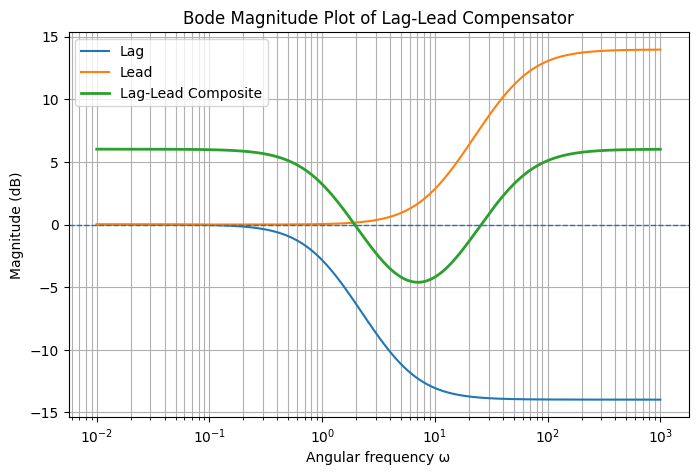

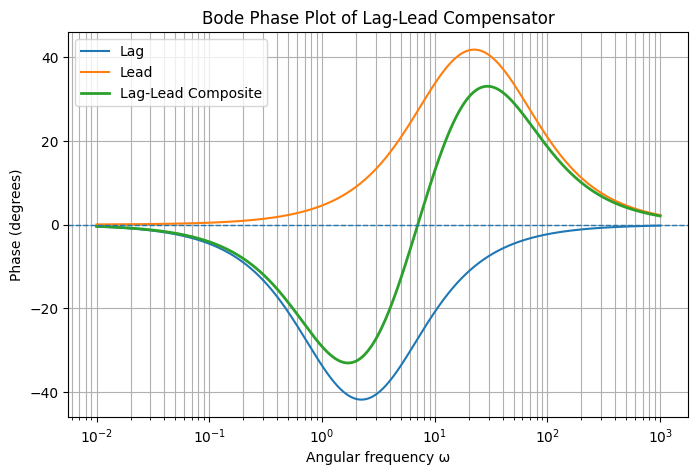

Analog composite low-frequency gain: 6.0201871814847285 dB
Analog composite high-frequency gain: 6.0102946024510775 dB
Analog composite peak gain: 6.0201871814847285 dB

Digital coefficients:
B0_lag = 0.9333333333333332
B1_lag = 0.39999999999999997
A1_lag = -0.3333333333333333
B0_lead = 2.3076923076923075
B1_lead = 1.5384615384615385
A1_lead = 0.923076923076923


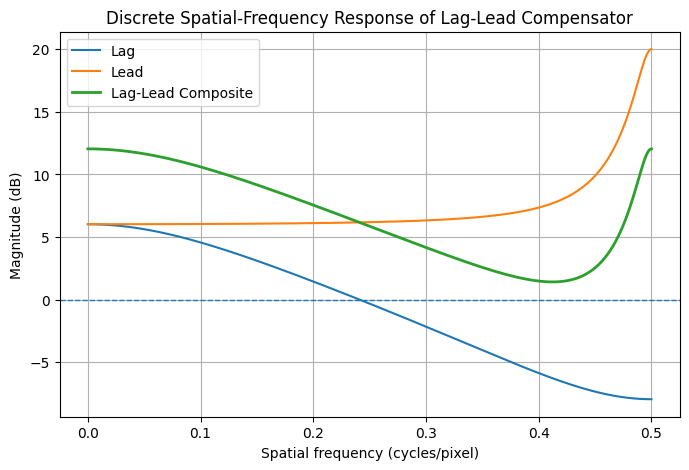


Digital composite gain at 0 cycles/pixel: 12.041199826561417 dB
Digital composite gain at Nyquist 0.5 cycles/pixel: 12.041199826561407 dB
Digital composite peak gain: 12.041199826561417 dB


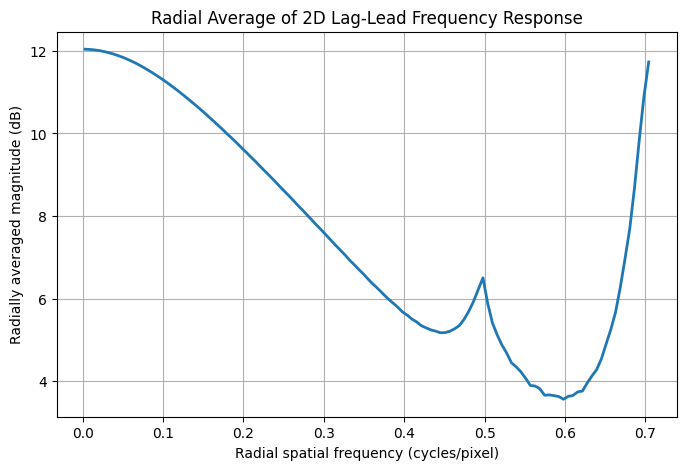


Saved figures in: /content/laglead_frequency_figures


In [ ]:
# =========================================================
# CLEAN LAG-LEAD FREQUENCY RESPONSE SCRIPT
# Solves shape mismatch error
# =========================================================

import os
import numpy as np
import matplotlib.pyplot as plt

SAVE_DIR = "/content/laglead_frequency_figures"
os.makedirs(SAVE_DIR, exist_ok=True)

# ---------------------------------------------------------
# Parameters
# ---------------------------------------------------------
K = 2.0
T1 = 0.2
T2 = 0.1
beta = 5.0
alpha = 0.2
Ts = 1.0

# =========================================================
# PART 1: ANALOG BODE RESPONSE
# =========================================================

w_analog = np.logspace(-2, 3, 2000)
s = 1j * w_analog

H_lag_analog = (1 + T1 * s) / (1 + beta * T1 * s)
H_lead_analog = (1 + T2 * s) / (1 + alpha * T2 * s)
H_comp_analog = K * H_lag_analog * H_lead_analog

mag_lag_analog_db = 20 * np.log10(np.abs(H_lag_analog) + 1e-12)
mag_lead_analog_db = 20 * np.log10(np.abs(H_lead_analog) + 1e-12)
mag_comp_analog_db = 20 * np.log10(np.abs(H_comp_analog) + 1e-12)

phase_lag_analog = np.angle(H_lag_analog, deg=True)
phase_lead_analog = np.angle(H_lead_analog, deg=True)
phase_comp_analog = np.angle(H_comp_analog, deg=True)

# Save analog Bode magnitude
plt.figure(figsize=(8, 5))
plt.semilogx(w_analog, mag_lag_analog_db, label="Lag")
plt.semilogx(w_analog, mag_lead_analog_db, label="Lead")
plt.semilogx(w_analog, mag_comp_analog_db, label="Lag-Lead Composite", linewidth=2)
plt.axhline(0, linestyle="--", linewidth=1)
plt.xlabel("Angular frequency ω")
plt.ylabel("Magnitude (dB)")
plt.title("Bode Magnitude Plot of Lag-Lead Compensator")
plt.grid(True, which="both")
plt.legend()
plt.savefig(os.path.join(SAVE_DIR, "bode_magnitude_laglead.png"), dpi=300, bbox_inches="tight")
plt.show()

# Save analog Bode phase
plt.figure(figsize=(8, 5))
plt.semilogx(w_analog, phase_lag_analog, label="Lag")
plt.semilogx(w_analog, phase_lead_analog, label="Lead")
plt.semilogx(w_analog, phase_comp_analog, label="Lag-Lead Composite", linewidth=2)
plt.axhline(0, linestyle="--", linewidth=1)
plt.xlabel("Angular frequency ω")
plt.ylabel("Phase (degrees)")
plt.title("Bode Phase Plot of Lag-Lead Compensator")
plt.grid(True, which="both")
plt.legend()
plt.savefig(os.path.join(SAVE_DIR, "bode_phase_laglead.png"), dpi=300, bbox_inches="tight")
plt.show()

print("Analog composite low-frequency gain:", mag_comp_analog_db[0], "dB")
print("Analog composite high-frequency gain:", mag_comp_analog_db[-1], "dB")
print("Analog composite peak gain:", np.max(mag_comp_analog_db), "dB")


# =========================================================
# PART 2: DIGITAL SPATIAL-FREQUENCY RESPONSE
# =========================================================

def bilinear_first_order(b0_s, b1_s, a0_s, a1_s, K, Ts):
    c = 2.0 / Ts

    num0 = b0_s + b1_s * c
    num1 = b0_s - b1_s * c

    den0 = a0_s + a1_s * c
    den1 = a0_s - a1_s * c

    B0 = K * num0 / den0
    B1 = K * num1 / den0
    A1 = den1 / den0

    return B0, B1, A1


def get_lag_lead_coefficients(K=1.0, T1=0.2, beta=5.0, T2=0.1, alpha=0.2, Ts=1.0):
    B0_lag, B1_lag, A1_lag = bilinear_first_order(
        b0_s=1.0,
        b1_s=T1,
        a0_s=1.0,
        a1_s=T1 * beta,
        K=K,
        Ts=Ts
    )

    B0_lead, B1_lead, A1_lead = bilinear_first_order(
        b0_s=1.0,
        b1_s=T2,
        a0_s=1.0,
        a1_s=alpha * T2,
        K=K,
        Ts=Ts
    )

    return {
        "B0_lag": B0_lag,
        "B1_lag": B1_lag,
        "A1_lag": A1_lag,
        "B0_lead": B0_lead,
        "B1_lead": B1_lead,
        "A1_lead": A1_lead
    }


coeffs = get_lag_lead_coefficients(
    K=K,
    T1=T1,
    beta=beta,
    T2=T2,
    alpha=alpha,
    Ts=Ts
)

print("\nDigital coefficients:")
for key, value in coeffs.items():
    print(key, "=", value)

freq_cpp = np.linspace(0, 0.5, 1000)   # cycles/pixel
omega_digital = 2 * np.pi * freq_cpp
z_inv = np.exp(-1j * omega_digital)

H_lag_digital = (
    coeffs["B0_lag"] + coeffs["B1_lag"] * z_inv
) / (
    1 + coeffs["A1_lag"] * z_inv
)

H_lead_digital = (
    coeffs["B0_lead"] + coeffs["B1_lead"] * z_inv
) / (
    1 + coeffs["A1_lead"] * z_inv
)

H_comp_digital = H_lag_digital * H_lead_digital

mag_lag_digital_db = 20 * np.log10(np.abs(H_lag_digital) + 1e-12)
mag_lead_digital_db = 20 * np.log10(np.abs(H_lead_digital) + 1e-12)
mag_comp_digital_db = 20 * np.log10(np.abs(H_comp_digital) + 1e-12)

plt.figure(figsize=(8, 5))
plt.plot(freq_cpp, mag_lag_digital_db, label="Lag")
plt.plot(freq_cpp, mag_lead_digital_db, label="Lead")
plt.plot(freq_cpp, mag_comp_digital_db, label="Lag-Lead Composite", linewidth=2)
plt.axhline(0, linestyle="--", linewidth=1)
plt.xlabel("Spatial frequency (cycles/pixel)")
plt.ylabel("Magnitude (dB)")
plt.title("Discrete Spatial-Frequency Response of Lag-Lead Compensator")
plt.grid(True)
plt.legend()
plt.savefig(os.path.join(SAVE_DIR, "discrete_spatial_frequency_response.png"), dpi=300, bbox_inches="tight")
plt.show()

print("\nDigital composite gain at 0 cycles/pixel:", mag_comp_digital_db[0], "dB")
print("Digital composite gain at Nyquist 0.5 cycles/pixel:", mag_comp_digital_db[-1], "dB")
print("Digital composite peak gain:", np.max(mag_comp_digital_db), "dB")


# =========================================================
# PART 3: 2D RADIAL AVERAGE RESPONSE
# =========================================================

def radial_average_2d_spectrum(spectrum_2d, fx, fy, num_bins=120):
    FX, FY = np.meshgrid(fx, fy)

    radius = np.sqrt(FX**2 + FY**2)

    radius_flat = radius.ravel()
    spectrum_flat = spectrum_2d.ravel()

    max_radius = np.max(radius_flat)

    bins = np.linspace(0, max_radius, num_bins + 1)

    radial_mean = []
    radial_centers = []

    for i in range(num_bins):
        mask = (radius_flat >= bins[i]) & (radius_flat < bins[i + 1])

        if np.any(mask):
            radial_mean.append(np.mean(spectrum_flat[mask]))
            radial_centers.append((bins[i] + bins[i + 1]) / 2)

    return np.array(radial_centers), np.array(radial_mean)


N = 512

fx = np.fft.fftshift(np.fft.fftfreq(N, d=1.0))
fy = np.fft.fftshift(np.fft.fftfreq(N, d=1.0))

FX, FY = np.meshgrid(fx, fy)

# Your Lag/Lead kernel is 1x2, so response is horizontal-frequency dependent
omega_x = 2 * np.pi * FX
z_inv_x = np.exp(-1j * omega_x)

H_lag_2d = (
    coeffs["B0_lag"] + coeffs["B1_lag"] * z_inv_x
) / (
    1 + coeffs["A1_lag"] * z_inv_x
)

H_lead_2d = (
    coeffs["B0_lead"] + coeffs["B1_lead"] * z_inv_x
) / (
    1 + coeffs["A1_lead"] * z_inv_x
)

H_comp_2d = H_lag_2d * H_lead_2d

mag_comp_2d_db = 20 * np.log10(np.abs(H_comp_2d) + 1e-12)

radial_freq_cpp, radial_mag_db = radial_average_2d_spectrum(
    mag_comp_2d_db,
    fx,
    fy,
    num_bins=120
)

plt.figure(figsize=(8, 5))
plt.plot(radial_freq_cpp, radial_mag_db, linewidth=2)
plt.xlabel("Radial spatial frequency (cycles/pixel)")
plt.ylabel("Radially averaged magnitude (dB)")
plt.title("Radial Average of 2D Lag-Lead Frequency Response")
plt.grid(True)
plt.savefig(os.path.join(SAVE_DIR, "radial_average_laglead_response.png"), dpi=300, bbox_inches="tight")
plt.show()

print("\nSaved figures in:", SAVE_DIR)

In [ ]:
# Correct global-gain implementation
K_global = 2.0

coeffs = get_lag_lead_coefficients(
    K=1.0,     # keep individual lag/lead coefficient gain as 1
    T1=0.2,
    beta=5.0,
    T2=0.1,
    alpha=0.2,
    Ts=1.0
)

H_lag_digital = (
    coeffs["B0_lag"] + coeffs["B1_lag"] * z_inv
) / (
    1 + coeffs["A1_lag"] * z_inv
)

H_lead_digital = (
    coeffs["B0_lead"] + coeffs["B1_lead"] * z_inv
) / (
    1 + coeffs["A1_lead"] * z_inv
)

H_comp_digital = K_global * H_lag_digital * H_lead_digital

mag_comp_digital_db = 20 * np.log10(np.abs(H_comp_digital) + 1e-12)

print("High-frequency gain:", mag_comp_digital_db[-1], "dB")

High-frequency gain: 6.020599913283954 dB


Correct digital coefficients without double K:
B0_lag = 0.4666666666666666
B1_lag = 0.19999999999999998
A1_lag = -0.3333333333333333
B0_lead = 1.1538461538461537
B1_lead = 0.7692307692307693
A1_lead = 0.923076923076923


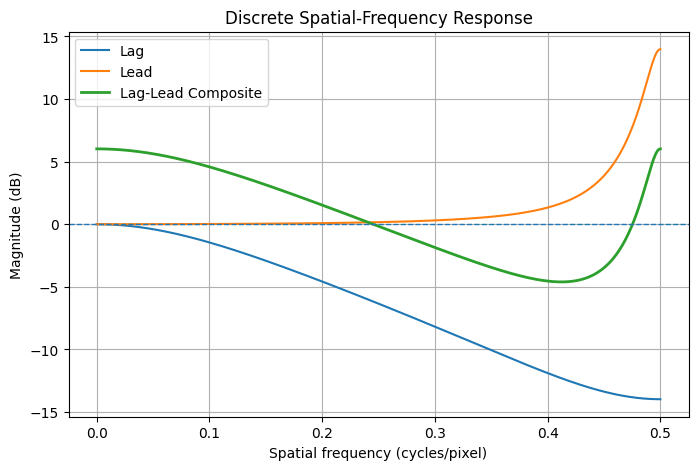

digital composite gain at 0 cycles/pixel: 6.020599913283965 dB
digital composite gain at Nyquist 0.5 cycles/pixel: 6.020599913283954 dB
digital composite peak gain: 6.020599913283965 dB


In [ ]:
# =========================================================
# CORRECT DIGITAL RESPONSE WITH GLOBAL K ONLY ONCE
# =========================================================

K_global = 2.0   # gives approximately +6 dB composite gain
T1 = 0.2
T2 = 0.1
beta = 5.0
alpha = 0.2
Ts = 1.0


def bilinear_first_order_no_gain(b0_s, b1_s, a0_s, a1_s, Ts):
    c = 2.0 / Ts

    num0 = b0_s + b1_s * c
    num1 = b0_s - b1_s * c

    den0 = a0_s + a1_s * c
    den1 = a0_s - a1_s * c

    B0 = num0 / den0
    B1 = num1 / den0
    A1 = den1 / den0

    return B0, B1, A1


def get_lag_lead_coefficients_correct(T1=0.2, beta=5.0, T2=0.1, alpha=0.2, Ts=1.0):
    B0_lag, B1_lag, A1_lag = bilinear_first_order_no_gain(
        b0_s=1.0,
        b1_s=T1,
        a0_s=1.0,
        a1_s=T1 * beta,
        Ts=Ts
    )

    B0_lead, B1_lead, A1_lead = bilinear_first_order_no_gain(
        b0_s=1.0,
        b1_s=T2,
        a0_s=1.0,
        a1_s=alpha * T2,
        Ts=Ts
    )

    return {
        "B0_lag": B0_lag,
        "B1_lag": B1_lag,
        "A1_lag": A1_lag,
        "B0_lead": B0_lead,
        "B1_lead": B1_lead,
        "A1_lead": A1_lead
    }


coeffs = get_lag_lead_coefficients_correct(
    T1=T1,
    beta=beta,
    T2=T2,
    alpha=alpha,
    Ts=Ts
)

print("Correct digital coefficients without double K:")
for key, value in coeffs.items():
    print(key, "=", value)

freq_cpp = np.linspace(0, 0.5, 1000)
omega_digital = 2 * np.pi * freq_cpp
z_inv = np.exp(-1j * omega_digital)

H_lag_digital = (
    coeffs["B0_lag"] + coeffs["B1_lag"] * z_inv
) / (
    1 + coeffs["A1_lag"] * z_inv
)

H_lead_digital = (
    coeffs["B0_lead"] + coeffs["B1_lead"] * z_inv
) / (
    1 + coeffs["A1_lead"] * z_inv
)

# Apply K only once here
H_comp_digital = K_global * H_lag_digital * H_lead_digital

mag_lag_digital_db = 20 * np.log10(np.abs(H_lag_digital) + 1e-12)
mag_lead_digital_db = 20 * np.log10(np.abs(H_lead_digital) + 1e-12)
mag_comp_digital_db = 20 * np.log10(np.abs(H_comp_digital) + 1e-12)

plt.figure(figsize=(8, 5))
plt.plot(freq_cpp, mag_lag_digital_db, label="Lag")
plt.plot(freq_cpp, mag_lead_digital_db, label="Lead")
plt.plot(freq_cpp, mag_comp_digital_db, label="Lag-Lead Composite", linewidth=2)
plt.axhline(0, linestyle="--", linewidth=1)
plt.xlabel("Spatial frequency (cycles/pixel)")
plt.ylabel("Magnitude (dB)")
plt.title("Discrete Spatial-Frequency Response")
plt.grid(True)
plt.legend()
plt.show()

print("digital composite gain at 0 cycles/pixel:", mag_comp_digital_db[0], "dB")
print("digital composite gain at Nyquist 0.5 cycles/pixel:", mag_comp_digital_db[-1], "dB")
print("digital composite peak gain:", np.max(mag_comp_digital_db), "dB")

In [ ]:
class LagLeadPreprocessing(tf.keras.layers.Layer):
    def __init__(self, K=1.0, T1=0.20, T2=0.10, **kwargs):
        super(LagLeadPreprocessing, self).__init__(**kwargs)

        # Non-trainable variables so we can change them for sensitivity analysis
        self.K_var = tf.Variable(K, trainable=False, dtype=tf.float32, name="K")
        self.T1_var = tf.Variable(T1, trainable=False, dtype=tf.float32, name="T1")
        self.T2_var = tf.Variable(T2, trainable=False, dtype=tf.float32, name="T2")

    def call(self, inputs):
        # Lag-like low-frequency smoothing
        lag = tf.nn.avg_pool2d(
            inputs,
            ksize=3,
            strides=1,
            padding="SAME"
        )

        # Lead-like high-frequency residual
        lead = inputs - lag

        # Parameterized lag-lead compensation
        output = self.K_var * (inputs + self.T1_var * lag + self.T2_var * lead)

        return output

    def get_config(self):
        config = super().get_config()
        config.update({
            "K": float(self.K_var.numpy()),
            "T1": float(self.T1_var.numpy()),
            "T2": float(self.T2_var.numpy())
        })
        return config

In [ ]:
tf.keras.backend.clear_session()

# Reference selected values
K_REF = 1.0
T1_REF = 0.20
T2_REF = 0.10

base_model_lag = tf.keras.applications.EfficientNetB3(
    include_top=False,
    weights="imagenet",
    input_shape=(IMG_SIZE[0], IMG_SIZE[1], 3)
)

base_model_lag.trainable = False

inputs = layers.Input(shape=(IMG_SIZE[0], IMG_SIZE[1], 3))

laglead_layer = LagLeadPreprocessing(
    K=K_REF,
    T1=T1_REF,
    T2=T2_REF,
    name="lag_lead_preprocessing"
)

x = laglead_layer(inputs)

x = base_model_lag(x, training=False)
x = layers.GlobalAveragePooling2D()(x)

x = layers.BatchNormalization()(x)
x = layers.Dropout(0.4)(x)

x = layers.Dense(
    128,
    activation="relu",
    kernel_regularizer=regularizers.l2(1e-4)
)(x)

x = layers.BatchNormalization()(x)
x = layers.Dropout(0.3)(x)

outputs = layers.Dense(1, activation="sigmoid")(x)

laglead_model = models.Model(inputs, outputs)

laglead_model.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss="binary_crossentropy",
    metrics=[
        "accuracy",
        tf.keras.metrics.Precision(name="precision"),
        tf.keras.metrics.Recall(name="recall"),
        tf.keras.metrics.AUC(name="auc")
    ]
)

laglead_model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 300, 300, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lag_lead_preprocessing          │ (None, 300, 300, 3)    │             0 │
│ (LagLeadPreprocessing)          │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb3 (Functional)     │ (None, 10, 10, 1536)   │    10,783,535 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1536)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 1536)           │         6,144 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1536)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       196,736 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10,987,056 (41.91 MB)

 Trainable params: 200,193 (782.00 KB)

 Non-trainable params: 10,786,863 (41.15 MB)

In [ ]:
checkpoint_lag = ModelCheckpoint(
    "best_xray_laglead_reference.keras",
    monitor="val_auc",
    mode="max",
    save_best_only=True,
    verbose=1
)

reduce_lr_lag = ReduceLROnPlateau(
    monitor="val_auc",
    mode="max",
    factor=0.5,
    patience=5,
    min_lr=1e-7,
    verbose=1
)

early_stop_lag = EarlyStopping(
    monitor="val_auc",
    mode="max",
    patience=12,
    restore_best_weights=True,
    verbose=1
)

history_lag = laglead_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=40,
    callbacks=[checkpoint_lag, reduce_lr_lag, early_stop_lag],
    class_weight=class_weight_dict,
    verbose=1
)

Epoch 1/40
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.5792 - auc: 0.5591 - loss: 0.9772 - precision: 0.7033 - recall: 0.5263
Epoch 1: val_auc improved from None to 0.49689, saving model to best_xray_laglead_reference.keras

Epoch 1: finished saving model to best_xray_laglead_reference.keras
22/22 ━━━━━━━━━━━━━━━━━━━━ 81s 2s/step - accuracy: 0.5291 - auc: 0.5418 - loss: 0.9559 - precision: 0.6585 - recall: 0.5047 - val_accuracy: 0.5946 - val_auc: 0.4969 - val_loss: 0.6945 - val_precision: 0.6250 - val_recall: 0.8696 - learning_rate: 1.0000e-04
Epoch 2/40
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 419ms/step - accuracy: 0.5405 - auc: 0.5076 - loss: 0.9800 - precision: 0.6900 - recall: 0.5548
Epoch 2: val_auc improved from 0.49689 to 0.54503, saving model to best_xray_laglead_reference.keras

Epoch 2: finished saving model to best_xray_laglead_reference.keras
22/22 ━━━━━━━━━━━━━━━━━━━━ 12s 571ms/step - accuracy: 0.5116 - auc: 0.5014 - loss: 1.0139 - precision: 0.6237 - recall: 0.5421 - val_ac

In [ ]:
best_laglead_model = tf.keras.models.load_model(
    "best_xray_laglead_reference.keras",
    custom_objects={"LagLeadPreprocessing": LagLeadPreprocessing}
)

In [ ]:
import numpy as np
import pandas as pd
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    matthews_corrcoef
)

def get_labels_from_sequence(seq):
    labels = []
    for i in range(len(seq)):
        _, y_batch = seq[i]
        y_batch = np.array(y_batch).ravel()
        labels.extend(y_batch)
    return np.array(labels).astype(int)

def evaluate_model_metrics(model, dataset, threshold=0.5):
    y_true = get_labels_from_sequence(dataset)

    y_prob = model.predict(dataset, verbose=0).ravel()
    y_pred = (y_prob >= threshold).astype(int)

    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    tn, fp, fn, tp = cm.ravel()

    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, zero_division=0)
    sensitivity = recall_score(y_true, y_pred, zero_division=0)
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
    f1 = f1_score(y_true, y_pred, zero_division=0)
    auc_score = roc_auc_score(y_true, y_prob)
    mcc = matthews_corrcoef(y_true, y_pred)

    return {
        "accuracy": accuracy,
        "precision": precision,
        "sensitivity": sensitivity,
        "specificity": specificity,
        "f1_score": f1,
        "auc": auc_score,
        "mcc": mcc,
        "tn": tn,
        "fp": fp,
        "fn": fn,
        "tp": tp,
        "probability_min": np.min(y_prob),
        "probability_max": np.max(y_prob),
        "probability_mean": np.mean(y_prob),
        "probability_std": np.std(y_prob)
    }

In [ ]:
# Get the lag-lead layer from trained model
sensitivity_layer = best_laglead_model.get_layer("lag_lead_preprocessing")

# Reference values
K_REF = 1.0
T1_REF = 0.20
T2_REF = 0.10

# Parameter ranges
K_values = [0.80, 0.90, 1.00, 1.10, 1.20]
T1_values = [0.10, 0.15, 0.20, 0.25, 0.30]
T2_values = [0.05, 0.075, 0.10, 0.125, 0.15]

sensitivity_results = []

def set_laglead_params(layer, K, T1, T2):
    layer.K_var.assign(float(K))
    layer.T1_var.assign(float(T1))
    layer.T2_var.assign(float(T2))

# -------------------------------
# Sensitivity for K
# -------------------------------
for K in K_values:
    set_laglead_params(sensitivity_layer, K=K, T1=T1_REF, T2=T2_REF)

    metrics = evaluate_model_metrics(best_laglead_model, test_ds)

    row = {
        "parameter_varied": "K",
        "K": K,
        "T1": T1_REF,
        "T2": T2_REF
    }
    row.update(metrics)
    sensitivity_results.append(row)

# -------------------------------
# Sensitivity for T1
# -------------------------------
for T1 in T1_values:
    set_laglead_params(sensitivity_layer, K=K_REF, T1=T1, T2=T2_REF)

    metrics = evaluate_model_metrics(best_laglead_model, test_ds)

    row = {
        "parameter_varied": "T1",
        "K": K_REF,
        "T1": T1,
        "T2": T2_REF
    }
    row.update(metrics)
    sensitivity_results.append(row)

# -------------------------------
# Sensitivity for T2
# -------------------------------
for T2 in T2_values:
    set_laglead_params(sensitivity_layer, K=K_REF, T1=T1_REF, T2=T2)

    metrics = evaluate_model_metrics(best_laglead_model, test_ds)

    row = {
        "parameter_varied": "T2",
        "K": K_REF,
        "T1": T1_REF,
        "T2": T2
    }
    row.update(metrics)
    sensitivity_results.append(row)

# Reset reference values after analysis
set_laglead_params(sensitivity_layer, K=K_REF, T1=T1_REF, T2=T2_REF)

sensitivity_df = pd.DataFrame(sensitivity_results)

sensitivity_df

,parameter_varied,K,T1,T2,accuracy,precision,sensitivity,specificity,f1_score,auc,mcc,tn,fp,fn,tp,probability_min,probability_max,probability_mean,probability_std
0,K,0.8,0.20,0.100,0.552632,0.733333,0.458333,0.714286,0.564103,0.666667,0.170353,10,4,13,11,0.020719,0.987106,0.464587,0.304538
1,K,0.9,0.20,0.100,0.526316,0.714286,0.416667,0.714286,0.526316,0.666667,0.130952,10,4,14,10,0.016764,0.982152,0.450715,0.295335
2,K,1.0,0.20,0.100,0.631579,0.812500,0.541667,0.785714,0.650000,0.782738,0.319854,11,3,11,13,0.016480,0.978262,0.446835,0.291785
3,K,1.1,0.20,0.100,0.578947,0.653846,0.708333,0.357143,0.680000,0.693452,0.067948,5,9,7,17,0.070112,0.976141,0.620926,0.292246
4,K,1.2,0.20,0.100,0.578947,0.700000,0.583333,0.571429,0.636364,0.645833,0.149514,8,6,10,14,0.042975,0.993573,0.583020,0.305000
5,T1,1.0,0.10,0.100,0.552632,0.705882,0.500000,0.642857,0.585366,0.708333,0.138592,9,5,12,12,0.014540,0.978864,0.470874,0.290507
6,T1,1.0,0.15,0.100,0.578947,0.833333,0.416667,0.857143,0.555556,0.690476,0.284146,12,2,14,10,0.017023,0.987071,0.423469,0.295431
7,T1,1.0,0.20,0.100,0.631579,0.812500,0.541667,0.785714,0.650000,0.782738,0.319854,11,3,11,13,0.016480,0.978262,0.446835,0.291785
8,T1,1.0,0.25,0.100,0.736842,0.850000,0.708333,0.785714,0.772727,0.758929,0.477295,11,3,7,17,0.034407,0.980410,0.520901,0.300159
9,T1,1.0,0.30,0.100,0.552632,0.640000,0.666667,0.357143,0.653061,0.702381,0.024209,5,9,8,16,0.056296,0.984941,0.600636,0.290168


In [ ]:
# Reference row: K=1.0, T1=0.20, T2=0.10
reference_metrics = evaluate_model_metrics(best_laglead_model, test_ds)

metrics_to_compare = [
    "accuracy",
    "precision",
    "sensitivity",
    "specificity",
    "f1_score",
    "auc",
    "mcc"
]

for metric in metrics_to_compare:
    sensitivity_df[f"{metric}_change_from_reference"] = (
        sensitivity_df[metric] - reference_metrics[metric]
    )

sensitivity_df.to_excel("xray_laglead_K_T1_T2_sensitivity_analysis.xlsx", index=False)

print("Saved: xray_laglead_K_T1_T2_sensitivity_analysis.xlsx")
sensitivity_df

Saved: xray_laglead_K_T1_T2_sensitivity_analysis.xlsx


,parameter_varied,K,T1,T2,accuracy,precision,sensitivity,specificity,f1_score,auc,...,probability_max,probability_mean,probability_std,accuracy_change_from_reference,precision_change_from_reference,sensitivity_change_from_reference,specificity_change_from_reference,f1_score_change_from_reference,auc_change_from_reference,mcc_change_from_reference
0,K,0.8,0.20,0.100,0.552632,0.733333,0.458333,0.714286,0.564103,0.666667,...,0.987106,0.464587,0.304538,-0.078947,-0.079167,-0.083333,-0.071429,-0.085897,-0.116071,-0.149501
1,K,0.9,0.20,0.100,0.526316,0.714286,0.416667,0.714286,0.526316,0.666667,...,0.982152,0.450715,0.295335,-0.105263,-0.098214,-0.125000,-0.071429,-0.123684,-0.116071,-0.188902
2,K,1.0,0.20,0.100,0.631579,0.812500,0.541667,0.785714,0.650000,0.782738,...,0.978262,0.446835,0.291785,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
3,K,1.1,0.20,0.100,0.578947,0.653846,0.708333,0.357143,0.680000,0.693452,...,0.976141,0.620926,0.292246,-0.052632,-0.158654,0.166667,-0.428571,0.030000,-0.089286,-0.251906
4,K,1.2,0.20,0.100,0.578947,0.700000,0.583333,0.571429,0.636364,0.645833,...,0.993573,0.583020,0.305000,-0.052632,-0.112500,0.041667,-0.214286,-0.013636,-0.136905,-0.170340
5,T1,1.0,0.10,0.100,0.552632,0.705882,0.500000,0.642857,0.585366,0.708333,...,0.978864,0.470874,0.290507,-0.078947,-0.106618,-0.041667,-0.142857,-0.064634,-0.074405,-0.181262
6,T1,1.0,0.15,0.100,0.578947,0.833333,0.416667,0.857143,0.555556,0.690476,...,0.987071,0.423469,0.295431,-0.052632,0.020833,-0.125000,0.071429,-0.094444,-0.092262,-0.035708
7,T1,1.0,0.20,0.100,0.631579,0.812500,0.541667,0.785714,0.650000,0.782738,...,0.978262,0.446835,0.291785,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
8,T1,1.0,0.25,0.100,0.736842,0.850000,0.708333,0.785714,0.772727,0.758929,...,0.980410,0.520901,0.300159,0.105263,0.037500,0.166667,0.000000,0.122727,-0.023810,0.157441
9,T1,1.0,0.30,0.100,0.552632,0.640000,0.666667,0.357143,0.653061,0.702381,...,0.984941,0.600636,0.290168,-0.078947,-0.172500,0.125000,-0.428571,0.003061,-0.080357,-0.295645


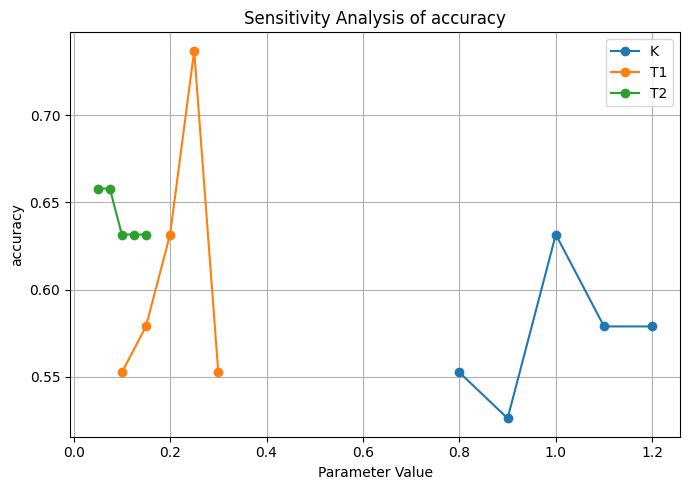

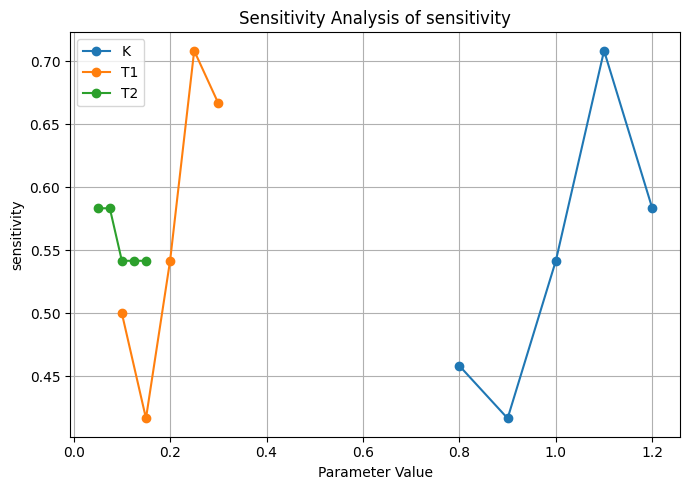

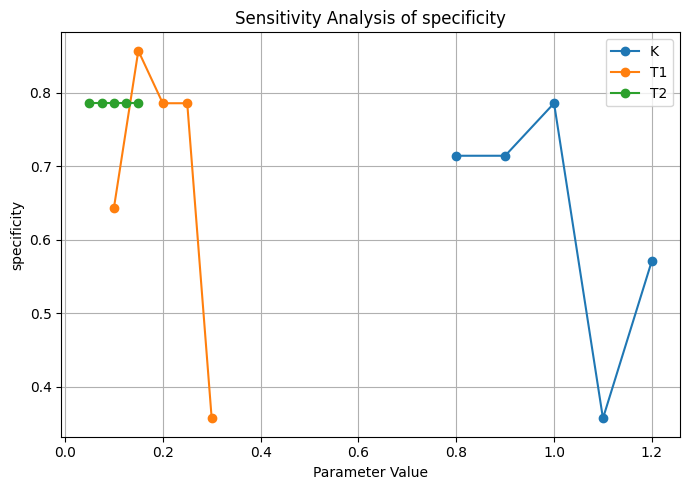

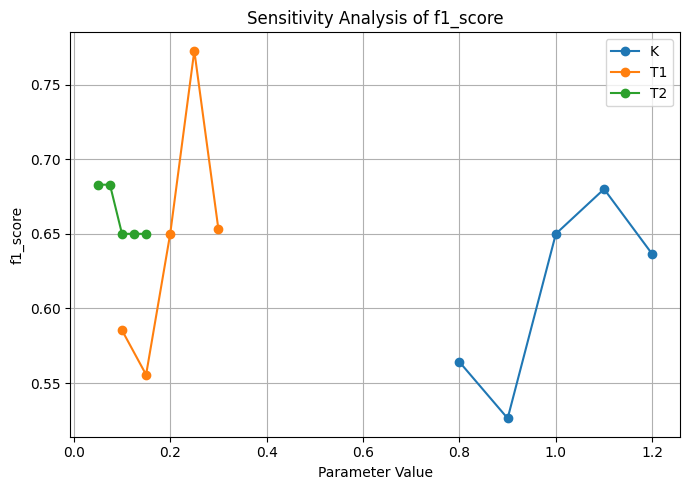

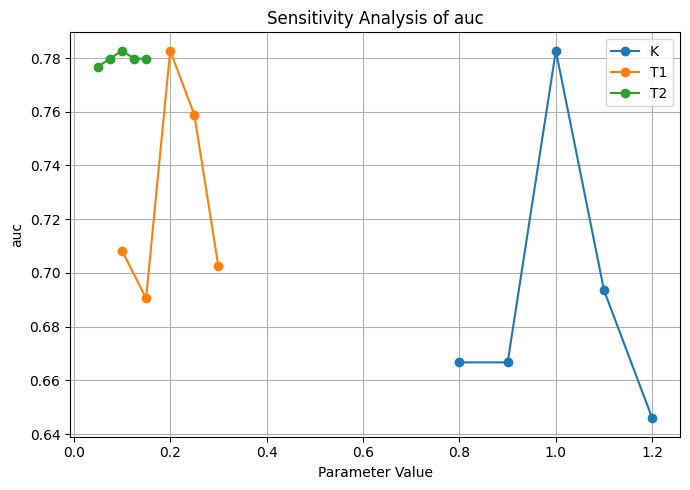

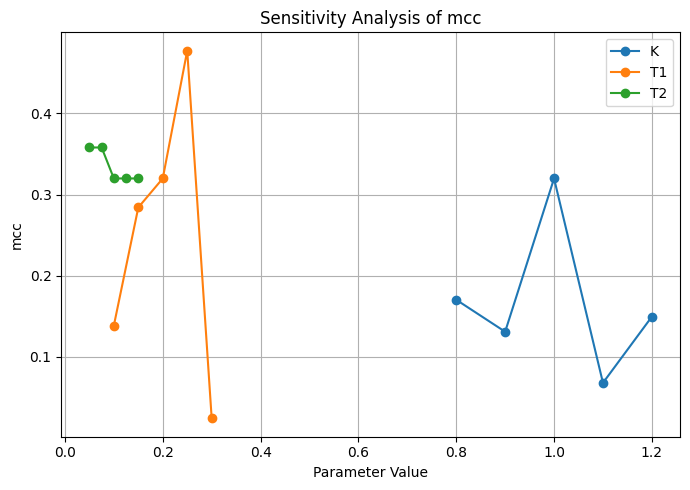

Saved sensitivity plots in: /content/sensitivity_figures


In [ ]:
import matplotlib.pyplot as plt
import os

SAVE_DIR = "/content/sensitivity_figures"
os.makedirs(SAVE_DIR, exist_ok=True)

def get_x_value(row):
    if row["parameter_varied"] == "K":
        return row["K"]
    elif row["parameter_varied"] == "T1":
        return row["T1"]
    else:
        return row["T2"]

sensitivity_df["varied_value"] = sensitivity_df.apply(get_x_value, axis=1)

metrics_to_plot = ["accuracy", "sensitivity", "specificity", "f1_score", "auc", "mcc"]

for metric in metrics_to_plot:
    plt.figure(figsize=(7, 5))

    for param in ["K", "T1", "T2"]:
        temp = sensitivity_df[sensitivity_df["parameter_varied"] == param]
        plt.plot(
            temp["varied_value"],
            temp[metric],
            marker="o",
            label=param
        )

    plt.xlabel("Parameter Value")
    plt.ylabel(metric)
    plt.title(f"Sensitivity Analysis of {metric}")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()

    filename = f"sensitivity_{metric}.png"
    plt.savefig(os.path.join(SAVE_DIR, filename), dpi=300, bbox_inches="tight")
    plt.show()

print("Saved sensitivity plots in:", SAVE_DIR)

In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from PIL import Image

In [ ]:
SAVE_DIR = "/content/gradcam_featuremaps"
os.makedirs(SAVE_DIR, exist_ok=True)

In [ ]:
def load_image_for_model(img_path, img_size=(300, 300)):
    img = Image.open(img_path).convert("RGB")
    img = img.resize(img_size)
    img_array = np.array(img).astype(np.float32)
    img_batch = np.expand_dims(img_array, axis=0)
    return img_array, img_batch

In [ ]:
for layer in best_laglead_model.layers:
    print(layer.name, type(layer).__name__)

input_layer_1 InputLayer
lag_lead_preprocessing LagLeadPreprocessing
efficientnetb3 Functional
global_average_pooling2d GlobalAveragePooling2D
batch_normalization BatchNormalization
dropout Dropout
dense Dense
batch_normalization_1 BatchNormalization
dropout_1 Dropout
dense_1 Dense


In [ ]:
def find_last_conv_layer(model):
    # Search inside nested models first
    for layer in reversed(model.layers):
        if isinstance(layer, tf.keras.Model):
            for sub_layer in reversed(layer.layers):
                if isinstance(sub_layer, tf.keras.layers.Conv2D):
                    return layer.name, sub_layer.name

    # Search top-level model
    for layer in reversed(model.layers):
        if isinstance(layer, tf.keras.layers.Conv2D):
            return None, layer.name

    raise ValueError("No Conv2D layer found.")

nested_model_name, last_conv_layer_name = find_last_conv_layer(best_laglead_model)

print("Nested model name:", nested_model_name)
print("Last conv layer name:", last_conv_layer_name)

Nested model name: efficientnetb3
Last conv layer name: top_conv


In [ ]:
def make_gradcam_heatmap_nested(model, img_batch, nested_model_name, last_conv_layer_name):
    # Get nested EfficientNet model
    if nested_model_name is not None:
        nested_model = model.get_layer(nested_model_name)
        last_conv_layer = nested_model.get_layer(last_conv_layer_name)

        # Build model from original input to last conv output and final prediction
        grad_model = tf.keras.models.Model(
            inputs=model.inputs,
            outputs=[
                last_conv_layer.output,
                model.output
            ]
        )

        # This direct method may fail for nested graph in some Keras versions
        # So use alternative below if error occurs

    else:
        last_conv_layer = model.get_layer(last_conv_layer_name)
        grad_model = tf.keras.models.Model(
            inputs=model.inputs,
            outputs=[last_conv_layer.output, model.output]
        )

    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_batch)

        # Binary classification malignant probability
        class_channel = predictions[:, 0]

    grads = tape.gradient(class_channel, conv_outputs)

    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    conv_outputs = conv_outputs[0]

    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)

    heatmap = tf.maximum(heatmap, 0)

    max_val = tf.reduce_max(heatmap)
    if max_val == 0:
        heatmap = heatmap
    else:
        heatmap = heatmap / max_val

    return heatmap.numpy(), predictions.numpy()[0][0]

In [ ]:
def get_efficientnet_submodel(model):
    for layer in model.layers:
        if isinstance(layer, tf.keras.Model):
            if "efficientnet" in layer.name.lower():
                return layer
    raise ValueError("EfficientNet submodel not found.")


def build_gradcam_model(model, last_conv_layer_name="top_conv"):
    efficientnet_model = get_efficientnet_submodel(model)

    last_conv_layer = efficientnet_model.get_layer(last_conv_layer_name)

    # Create a model that outputs EfficientNet last conv output
    conv_model = tf.keras.models.Model(
        efficientnet_model.input,
        last_conv_layer.output
    )

    return efficientnet_model, conv_model


def make_gradcam_heatmap(model, img_batch, last_conv_layer_name="top_conv"):
    efficientnet_model, conv_model = build_gradcam_model(
        model,
        last_conv_layer_name=last_conv_layer_name
    )

    with tf.GradientTape() as tape:
        # Pass image through lag-lead layer if present
        x = img_batch

        for layer in model.layers:
            if layer.name == "lag_lead_preprocessing":
                x = layer(x)
                break

        conv_outputs = conv_model(x)
        tape.watch(conv_outputs)

        # Now continue through EfficientNet from input is difficult,
        # so use full model prediction for probability
        preds = model(img_batch, training=False)
        class_channel = preds[:, 0]

    grads = tape.gradient(class_channel, conv_outputs)

    if grads is None:
        raise ValueError(
            "Gradients are None. Use the alternative Grad-CAM model function below."
        )

    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    conv_outputs = conv_outputs[0]

    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)

    heatmap = tf.maximum(heatmap, 0)

    if tf.reduce_max(heatmap) != 0:
        heatmap = heatmap / tf.reduce_max(heatmap)

    return heatmap.numpy(), preds.numpy()[0][0]

In [ ]:
def create_gradcam_model_for_laglead(model, last_conv_layer_name="top_conv"):
    # Find EfficientNetB3 submodel
    efficientnet_model = None

    for layer in model.layers:
        if isinstance(layer, tf.keras.Model):
            if "efficientnet" in layer.name.lower():
                efficientnet_model = layer
                break

    if efficientnet_model is None:
        raise ValueError("EfficientNetB3 submodel not found inside model.")

    # Get last conv layer
    last_conv_layer = efficientnet_model.get_layer(last_conv_layer_name)

    # New model: EfficientNet input -> last conv output and EfficientNet final feature output
    efficientnet_grad_model = tf.keras.models.Model(
        inputs=efficientnet_model.input,
        outputs=[
            last_conv_layer.output,
            efficientnet_model.output
        ]
    )

    return efficientnet_model, efficientnet_grad_model


def gradcam_laglead(model, img_batch, last_conv_layer_name="top_conv"):
    efficientnet_model, efficientnet_grad_model = create_gradcam_model_for_laglead(
        model,
        last_conv_layer_name=last_conv_layer_name
    )

    # Get layers after EfficientNetB3
    after_effnet = False
    post_layers = []

    for layer in model.layers:
        if layer == efficientnet_model:
            after_effnet = True
            continue
        if after_effnet:
            post_layers.append(layer)

    # Apply lag-lead preprocessing if present
    x = img_batch
    for layer in model.layers:
        if layer.name == "lag_lead_preprocessing":
            x = layer(x)
            break

    with tf.GradientTape() as tape:
        conv_outputs, effnet_output = efficientnet_grad_model(x)

        z = effnet_output
        for layer in post_layers:
            z = layer(z, training=False)

        prediction = z
        class_channel = prediction[:, 0]

    grads = tape.gradient(class_channel, conv_outputs)

    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    conv_outputs = conv_outputs[0]

    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)

    heatmap = tf.maximum(heatmap, 0)

    max_value = tf.reduce_max(heatmap)
    if max_value != 0:
        heatmap = heatmap / max_value

    return heatmap.numpy(), prediction.numpy()[0][0]

In [ ]:
def overlay_gradcam(img_array, heatmap, alpha=0.4):
    img = img_array.astype(np.uint8)

    heatmap_resized = tf.image.resize(
        heatmap[..., np.newaxis],
        (img.shape[0], img.shape[1])
    ).numpy().squeeze()

    heatmap_uint8 = np.uint8(255 * heatmap_resized)

    cmap = plt.cm.jet
    colored_heatmap = cmap(heatmap_uint8 / 255.0)[:, :, :3]
    colored_heatmap = np.uint8(255 * colored_heatmap)

    overlay = np.uint8((1 - alpha) * img + alpha * colored_heatmap)

    return overlay, heatmap_resized

In [ ]:
# Choose image index
idx = 0

img_path = X_test[idx]
true_label = y_test[idx]

img_array, img_batch = load_image_for_model(img_path, IMG_SIZE)

heatmap, pred_prob = gradcam_laglead(
    best_laglead_model,
    img_batch,
    last_conv_layer_name="top_conv"
)

overlay_img, heatmap_resized = overlay_gradcam(img_array, heatmap, alpha=0.4)

pred_label = 1 if pred_prob >= 0.5 else 0

class_names = ["Benign", "Malignant"]

print("Image path:", img_path)
print("True label:", class_names[true_label])
print("Predicted probability:", pred_prob)
print("Predicted label:", class_names[pred_label])

Image path: /content/dataset/XRAYNEW/Benign/JPCNN025.jpg
True label: Benign
Predicted probability: 0.60732967
Predicted label: Malignant


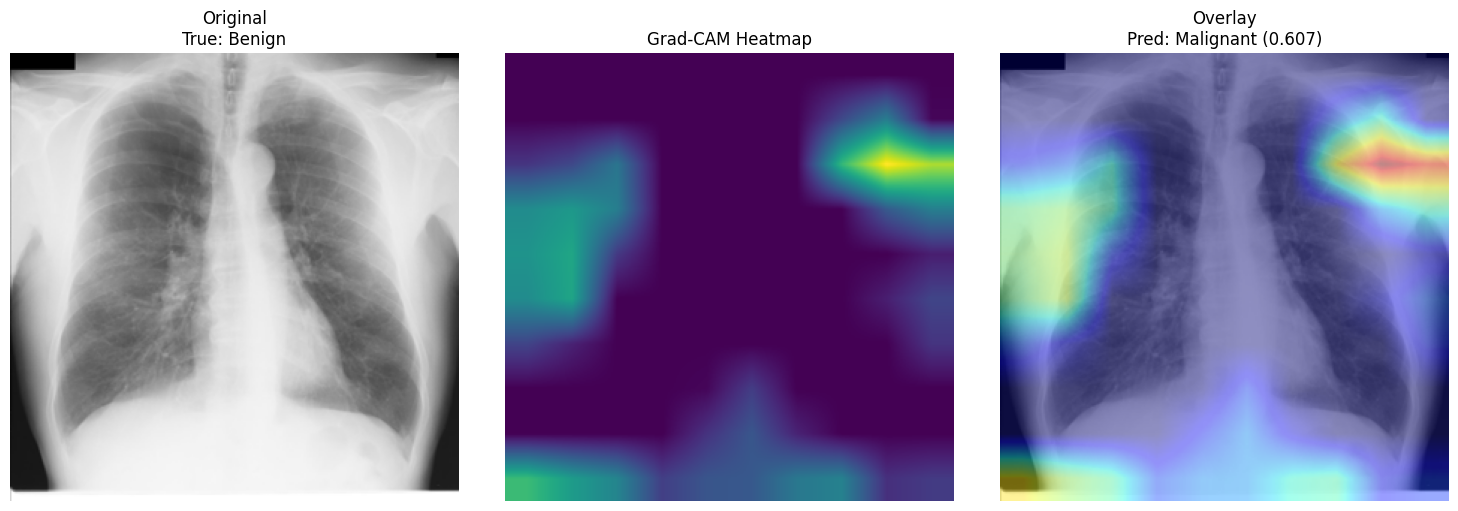

Saved: /content/gradcam_featuremaps/gradcam_sample_0.png


In [ ]:
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(img_array.astype(np.uint8))
plt.title(f"Original\nTrue: {class_names[true_label]}")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(heatmap_resized)
plt.title("Grad-CAM Heatmap")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(overlay_img)
plt.title(f"Overlay\nPred: {class_names[pred_label]} ({pred_prob:.3f})")
plt.axis("off")

plt.tight_layout()

save_path = os.path.join(SAVE_DIR, f"gradcam_sample_{idx}.png")
plt.savefig(save_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", save_path)

In [ ]:
def get_feature_maps(model, img_batch, layer_name="top_conv"):
    efficientnet_model = get_efficientnet_submodel(model)

    feature_model = tf.keras.models.Model(
        inputs=efficientnet_model.input,
        outputs=efficientnet_model.get_layer(layer_name).output
    )

    # Apply lag-lead preprocessing if present
    x = img_batch
    for layer in model.layers:
        if layer.name == "lag_lead_preprocessing":
            x = layer(x)
            break

    feature_maps = feature_model.predict(x, verbose=0)

    return feature_maps

Feature map shape: (1, 10, 10, 1536)


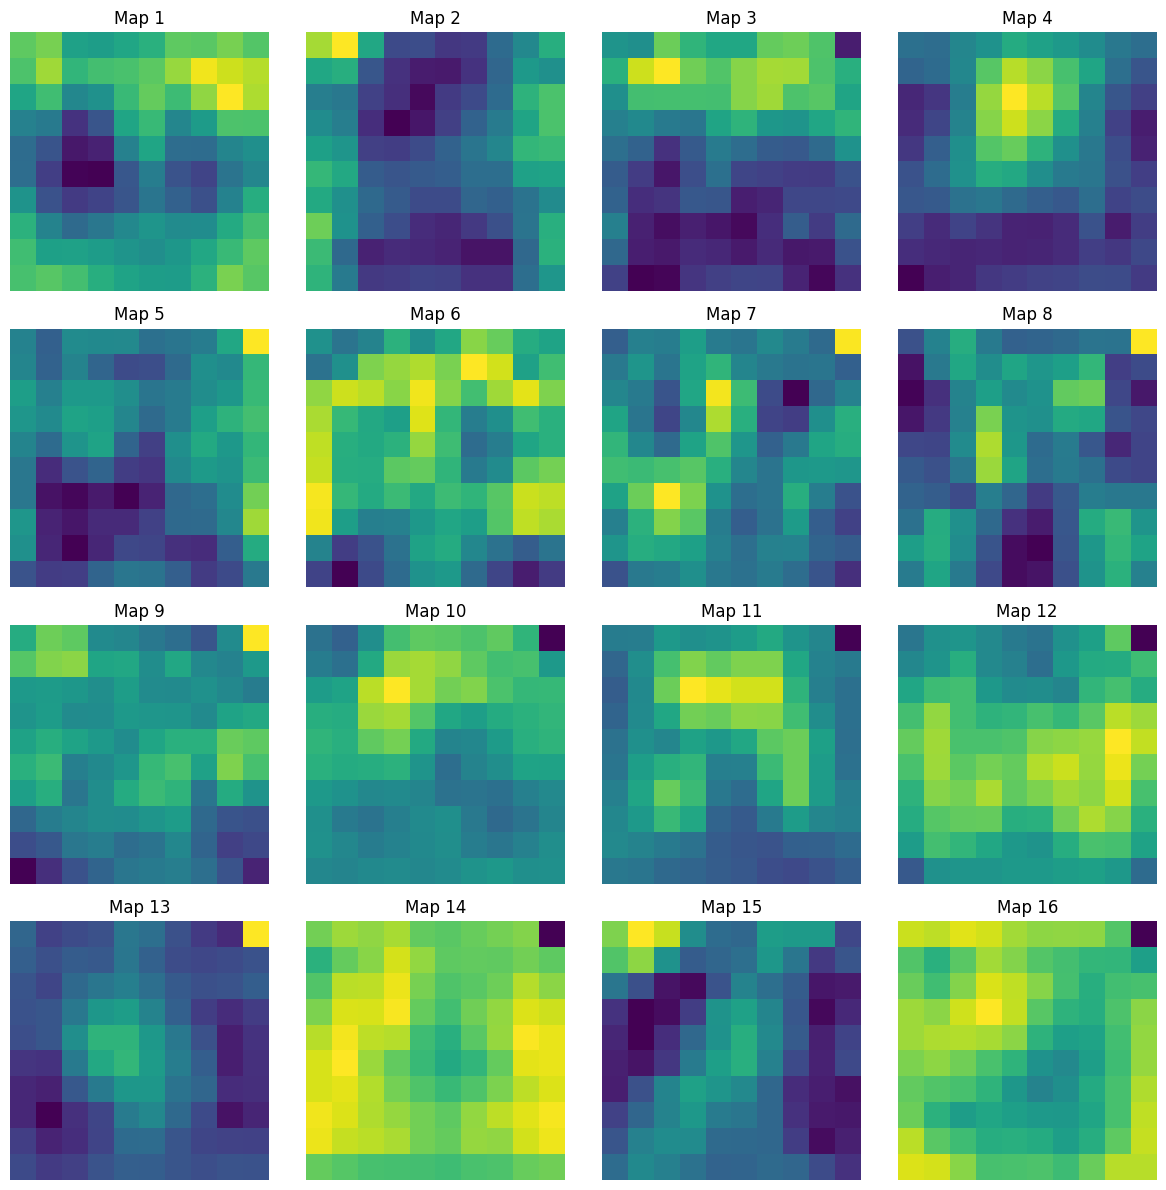

Saved: /content/gradcam_featuremaps/feature_maps_sample_0.png


In [ ]:
feature_maps = get_feature_maps(
    best_laglead_model,
    img_batch,
    layer_name="top_conv"
)

print("Feature map shape:", feature_maps.shape)

num_maps = 16

plt.figure(figsize=(12, 12))

for i in range(num_maps):
    fmap = feature_maps[0, :, :, i]

    plt.subplot(4, 4, i + 1)
    plt.imshow(fmap)
    plt.title(f"Map {i+1}")
    plt.axis("off")

plt.tight_layout()

feature_save_path = os.path.join(SAVE_DIR, f"feature_maps_sample_{idx}.png")
plt.savefig(feature_save_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", feature_save_path)